# 03 — Task 2.1.2: Pre-trained Transformer Baseline
Applies `distilbert-base-uncased-finetuned-sst-2-english` to the IMDB test set **without any fine-tuning**.

In [1]:
import sys
sys.path.insert(0, '..')

from tqdm import tqdm
import pandas as pd

from src.utils import load_data, evaluate_predictions, save_results

test_texts, test_labels = load_data('test')
print(f'Test set: {len(test_texts):,} reviews')

Test set: 2,000 reviews


## 1. Load pipeline

In [2]:
from transformers import pipeline

MODEL = 'distilbert-base-uncased-finetuned-sst-2-english'

# truncation=True handles reviews longer than 512 tokens
classifier = pipeline(
    'sentiment-analysis',
    model=MODEL,
    truncation=True,
    max_length=512,
    device=-1,  # CPU; set to 0 for GPU
)
print(f'Loaded: {MODEL}')

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded: distilbert-base-uncased-finetuned-sst-2-english


## 2. Run inference

In [3]:
BATCH_SIZE = 32

raw_preds = []
for i in tqdm(range(0, len(test_texts), BATCH_SIZE), desc='DistilBERT inference'):
    batch = test_texts[i:i+BATCH_SIZE]
    results = classifier(batch)
    raw_preds.extend(results)

# Map POSITIVE/NEGATIVE → pos/neg
preds = ['pos' if r['label'] == 'POSITIVE' else 'neg' for r in raw_preds]
print(f'Done. Sample: {raw_preds[:3]}')

DistilBERT inference: 100%|██████████| 63/63 [00:46<00:00,  1.37it/s]

Done. Sample: [{'label': 'NEGATIVE', 'score': 0.9970535039901733}, {'label': 'NEGATIVE', 'score': 0.9994359612464905}, {'label': 'POSITIVE', 'score': 0.9983038902282715}]


## 3. Evaluate

In [4]:
metrics = evaluate_predictions(test_labels, preds)
print('Pre-trained DistilBERT (SST-2):', metrics)

save_results(
    task='2.1.2',
    approach='DistilBERT (pre-trained, SST-2)',
    metrics=metrics,
    preprocessing='truncation to 512 tokens',
    notes='No fine-tuning; zero-shot transfer from SST-2 to IMDB'
)

Pre-trained DistilBERT (SST-2): {'accuracy': 0.9, 'precision': 0.9228, 'recall': 0.8777, 'f1': 0.8997}
Saved: [2.1.2] DistilBERT (pre-trained, SST-2) — acc=0.9 f1=0.8997


## 4. Confidence score distribution

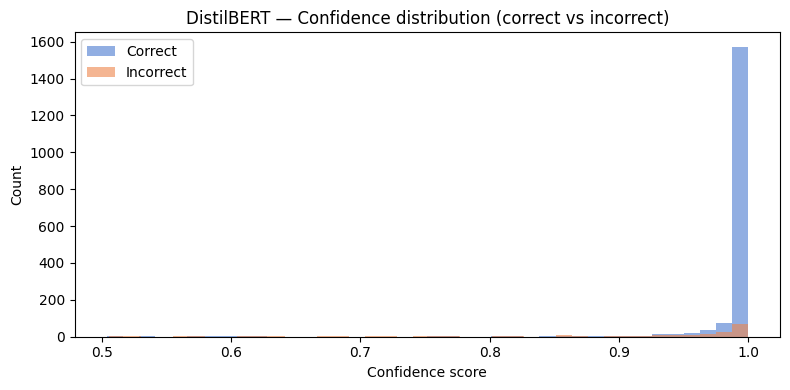

Accuracy: 0.9 | F1: 0.8997


In [5]:
import matplotlib.pyplot as plt

scores = [r['score'] for r in raw_preds]
correct = [p == t for p, t in zip(preds, test_labels)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([s for s, c in zip(scores, correct) if c],
        bins=40, alpha=0.6, label='Correct', color='#4878D0')
ax.hist([s for s, c in zip(scores, correct) if not c],
        bins=40, alpha=0.6, label='Incorrect', color='#EE854A')
ax.set_xlabel('Confidence score')
ax.set_ylabel('Count')
ax.set_title('DistilBERT — Confidence distribution (correct vs incorrect)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/fig_distilbert_baseline_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Accuracy: {metrics['accuracy']} | F1: {metrics['f1']}")